In [1]:
import pandas as pd
import re
import json


input_path = "mskang_.txt"  

with open(input_path, "r", encoding="utf-8") as f:
    text = f.read()

pattern = r"(\/[^\n]+\/(normal|abnormal)\/[^\n]+)\s*[\s\S]*?(?:```json\s*([\s\S]*?)\s*```|(\{[\s\S]*?\}))"
matches = re.findall(pattern, text, re.DOTALL)

rows = []

for match in matches:
    
    path, truth, json_block, json_raw = match
    json_str = json_block if json_block else json_raw
    
    try:
        data = json.loads(json_str)

        is_scam = bool(data.get("is_scam"))

        if (is_scam and truth == "abnormal") or (not is_scam and truth == "normal"):
            result = True
        else:
            result = False

        rows.append({
            "filename": path.split("/")[-1].strip(),
            "truth": truth,
            "is_scam": data.get("is_scam"),
            "result": result,
            "is_correct": data.get("is_scam"),
            "confidence": data.get("confidence"),
            "risk": data.get("risk"),
            "evidence": "; ".join(data.get("evidence", [])),
            "explanation": data.get("explanation"),            
        })
    except json.JSONDecodeError as e:
        print(f"JSON 파싱 오류 발생 ({path}): {e}")

df = pd.DataFrame(rows, columns=["filename", "truth", "is_scam", "result", "confidence", "risk", "evidence", "explanation"])

output_path = "scam_results.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"CSV 파일 생성 완료: {output_path}")
print(df)


JSON 파싱 오류 발생 (/home/ubuntu/video_20251104/normal/0015.mp4): Expecting ',' delimiter: line 11 column 185 (char 462)
JSON 파싱 오류 발생 (/home/ubuntu/video_20251104/abnormal/0014.mp4): Expecting ',' delimiter: line 7 column 19 (char 145)
CSV 파일 생성 완료: scam_results.csv
    filename     truth  is_scam  result  confidence  risk  \
0   0011.mp4    normal    False    True        0.90   low   
1   0024.mp4    normal     True   False        0.95  high   
2   0004.mp4    normal     True   False        0.95  high   
3   0001.mp4    normal     True   False        0.95  high   
4   0006.mp4    normal     True   False        0.90  high   
5   0016.mp4    normal    False    True        0.80   low   
6   0005.mp4    normal    False    True        0.80   low   
7   0018.mp4    normal    False    True        0.95   low   
8   0023.mp4    normal    False    True        0.95   low   
9   0007.mp4    normal    False    True        0.95   low   
10  0014.mp4    normal     True   False        0.95  high   
11  0

In [2]:
df.groupby(["truth", "result"]).agg({"filename":"count"})

filename
truth    result          
abnormal False          6
         True          20
normal   False         14
         True          12

In [3]:
df[df['result']==True]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
0,0011.mp4,normal,False,True,0.90,low,No monetary requests or solicitations are ment...,The content focuses on daily activities and pe...
5,0016.mp4,normal,False,True,0.80,low,The video shows a person solving a Rubik's cub...,The content appears to be about demonstrating ...
6,0005.mp4,normal,False,True,0.80,low,No visible monetary solicitations; No external...,The video lacks clear indicators of fraud such...
7,0018.mp4,normal,False,True,0.95,low,No prepayment or financial requests are mentio...,The video seems non-fraudulent as it primarily...
8,0023.mp4,normal,False,True,0.95,low,The video features cooking scenes with Korean ...,The content is about demonstrating the versati...
9,0007.mp4,normal,False,True,0.95,low,Video shows a person completing tasks for mone...,The content does not display clear indicators ...
11,0021.mp4,normal,False,True,0.60,low,Promotional content for a job role (Benwon Don...,The video promotes career development in the f...
12,0027.mp4,normal,False,True,0.85,low,Contains nutritional information for daily cal...,The video provides educational content about d...
17,0022.mp4,normal,False,True,0.98,low,"The video features a product from Dyson, which...",The content focuses on showcasing the design a...
18,0019.mp4,normal,False,True,0.95,low,Informational or Educational Purpose,The video primarily serves an informational an...


In [4]:
df[df['result']==False]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
1,0024.mp4,normal,True,False,0.95,high,"Promises significant financial returns (e.g., ...",The video appears to be a scam due to the emph...
2,0004.mp4,normal,True,False,0.95,high,"Repeated mentions of booking rooms, showing ur...",The video exhibits strong indicators typical o...
3,0001.mp4,normal,True,False,0.95,high,"MZ는 왜 이제アルバ리를 안할까?; 2025년 최저임금 인상 확정 10,030원; ...",The video contains strong indicators of a scam...
4,0006.mp4,normal,True,False,0.90,high,"Monetary solicitation: Prepayment, fees, or de...",The video includes strong indicators of a scam...
10,0014.mp4,normal,True,False,0.95,high,Monetary requests or claims of guaranteed retu...,The video contains indicators suggesting a sca...
13,0012.mp4,normal,True,False,0.90,high,Prepayment or deposit request mentioned (as in...,The video includes indicators suggesting fraud...
14,0010.mp4,normal,True,False,0.95,high,Monetary solicitation with phrases like 'Give ...,The video contains strong indications typical ...
15,0003.mp4,normal,True,False,0.90,high,Monetary requests or promises of financial gai...,The video contains strong indicators that it i...
16,0002.mp4,normal,True,False,0.95,high,Monetary transaction request (asking for money...,The video shows elements typical of scams: req...
19,0008.mp4,normal,True,False,0.95,high,Monetary solicitations; External channel promo...,The video promotes a job opportunity that appe...


Precision: [0.5        0.50980392 0.5        0.51111111 0.48484848 0.66666667
 0.5        1.        ]
Recall: [1.         1.         0.88461538 0.88461538 0.61538462 0.07692308
 0.03846154 0.        ]
AP (mAP): 0.5024


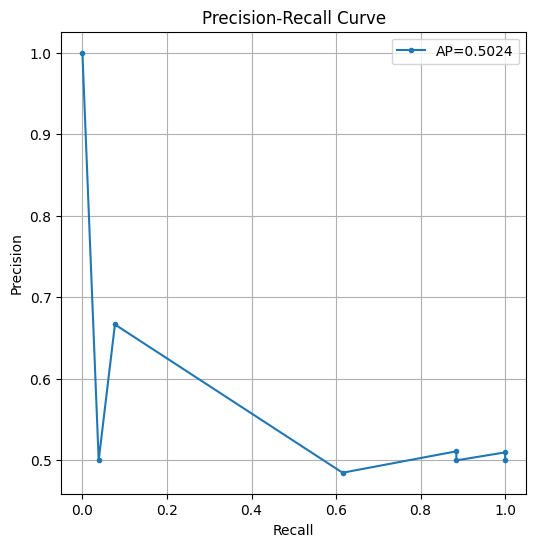

Optimal threshold (F1 max): 0.80


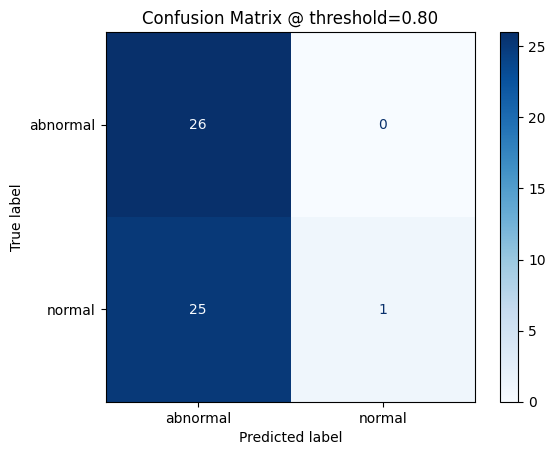

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

# abnormal = positive class
df['y_true'] = df['truth'].apply(lambda x: 1 if x=='abnormal' else 0)
y_true = df['y_true'].values
y_scores = df['confidence'].values

# Precision-Recall + AP
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"AP (mAP): {ap:.4f}")

# PR curve 시각화
plt.figure(figsize=(6,6))
plt.plot(recall, precision, marker='.', label=f'AP={ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# 최적 threshold 선택 (F1 최대)
f1_scores = 2*precision*recall/(precision+recall+1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (F1 max): {best_threshold:.2f}")

# Confusion matrix
y_pred = (y_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(cm, display_labels=['abnormal', 'normal'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={best_threshold:.2f}')
plt.show()
